In [ ]:
# Install the package needed to download financial data
!pip install yfinance --quiet

# Import the packages we will use
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make charts look clearer
plt.style.use("seaborn-v0_8-whitegrid")

# ---------------------------
# 1. Choose the assets
# ---------------------------

# VT  = broad global equities
# IEF = US government bonds
# BIL = short-term US Treasury bills, used as our cash proxy
tickers = {
    "Equities": "VT",
    "Bonds": "IEF",
    "Cash": "BIL"
}

start_date = "2008-07-01"
end_date = "2026-07-01"

# ---------------------------
# 2. Download daily prices
# ---------------------------

downloaded_data = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

# Keep the adjusted closing prices only
daily_prices = downloaded_data["Close"].copy()

# Rename ticker columns so they are easier to read
daily_prices = daily_prices.rename(
    columns={
        "VT": "Equities",
        "IEF": "Bonds",
        "BIL": "Cash"
    }
)

# Remove any rows with missing prices
daily_prices = daily_prices.dropna()



Analysis starts: 2009-07-31
Analysis ends: 2026-06-30


,Equities,Bonds,Cash
Date,,,
2009-07-31,0.6,0.0,0.4
2009-08-31,0.6,0.0,0.4
2009-09-30,0.6,0.0,0.4
2009-10-31,0.6,0.4,0.0
2009-11-30,0.6,0.4,0.0


,Static 60/40 portfolio,Trend-following portfolio
Final value of £1,3.858868,2.646503
CAGR,0.082674,0.058920
Annualised volatility,0.092239,0.065753
Sharpe ratio,0.771483,0.710526
Maximum drawdown,-0.215563,-0.078369
Worst calendar year,-0.166238,-0.050443


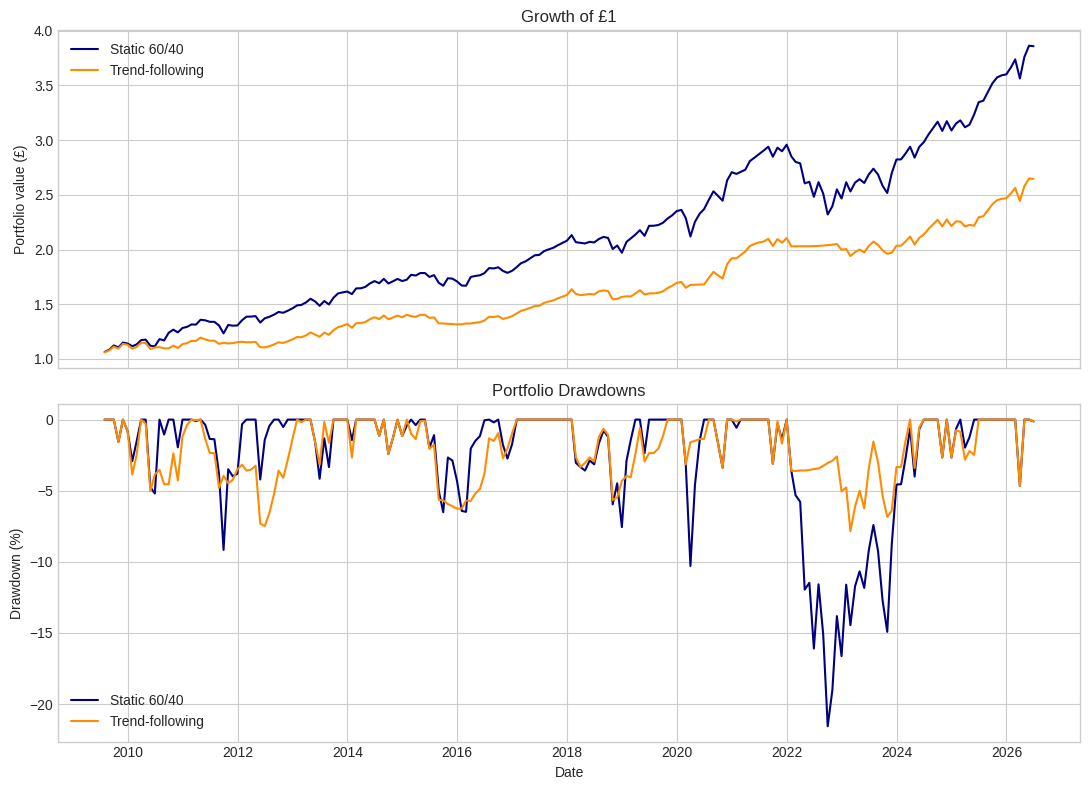

In [ ]:
# ---------------------------
# 3. Choose the common test period
# ---------------------------

# Start after 12 months so that later moving-average tests
# use the same period as the benchmark.
analysis_start_date = monthly_prices.index[12]

analysis_returns = monthly_returns.loc[
    monthly_returns.index >= analysis_start_date
].copy()

print("Analysis starts:", analysis_returns.index[0].date())
print("Analysis ends:", analysis_returns.index[-1].date())


# ---------------------------
# 4. Static 60/40 portfolio
# ---------------------------

benchmark_returns = (
    0.60 * analysis_returns["Equities"]
    + 0.40 * analysis_returns["Bonds"]
)

benchmark_wealth = (
    1 + benchmark_returns
).cumprod()

benchmark_drawdown = (
    benchmark_wealth / benchmark_wealth.cummax() - 1
)


# ---------------------------
# 5. Benchmark performance measures
# ---------------------------

years = len(benchmark_returns) / 12

benchmark_cagr = (
    benchmark_wealth.iloc[-1] ** (1 / years) - 1
)

benchmark_volatility = (
    benchmark_returns.std() * np.sqrt(12)
)

benchmark_excess_returns = (
    benchmark_returns - analysis_returns["Cash"]
)

benchmark_sharpe = (
    benchmark_excess_returns.mean()
    / benchmark_excess_returns.std()
    * np.sqrt(12)
)

benchmark_max_drawdown = benchmark_drawdown.min()

benchmark_yearly_returns = benchmark_returns.resample(
    "YE"
).apply(
    lambda x: (1 + x).prod() - 1
)

benchmark_worst_year = benchmark_yearly_returns.min()

# ---------------------------
# 6. Ten-month moving averages
# ---------------------------

equity_moving_average = monthly_prices["Equities"].rolling(
    window=10
).mean()

bond_moving_average = monthly_prices["Bonds"].rolling(
    window=10
).mean()


# ---------------------------
# 7. Create the trend signals
# ---------------------------

# Signal = 1 when the asset is above its moving average
# Signal = 0 when the asset is below its moving average
equity_signal = (
    monthly_prices["Equities"] > equity_moving_average
).astype(int)

bond_signal = (
    monthly_prices["Bonds"] > bond_moving_average
).astype(int)

# Shift each signal forward by one month.
# The signal at the end of month t is used during month t + 1.
equity_signal = equity_signal.shift(1)
bond_signal = bond_signal.shift(1)

# Keep only the same dates used for the 60/40 benchmark
equity_signal = equity_signal.loc[analysis_returns.index]
bond_signal = bond_signal.loc[analysis_returns.index]


# ---------------------------
# 8. Create portfolio weights
# ---------------------------

# If the equity signal is 1, invest 60% in equities.
# If it is 0, that 60% is held in cash.
trend_equity_weight = 0.60 * equity_signal

# If the bond signal is 1, invest 40% in bonds.
# If it is 0, that 40% is held in cash.
trend_bond_weight = 0.40 * bond_signal

# Whatever is not in equities or bonds is held in cash.
trend_cash_weight = (
    1
    - trend_equity_weight
    - trend_bond_weight
)

# Display the first few portfolio weights
trend_weights = pd.DataFrame(
    {
        "Equities": trend_equity_weight,
        "Bonds": trend_bond_weight,
        "Cash": trend_cash_weight
    }
)

display(trend_weights.head())


# ---------------------------
# 9. Calculate trend-following returns
# ---------------------------

trend_returns = (
    trend_equity_weight * analysis_returns["Equities"]
    + trend_bond_weight * analysis_returns["Bonds"]
    + trend_cash_weight * analysis_returns["Cash"]
)

# Begin with £1 and compound the monthly returns
trend_wealth = (1 + trend_returns).cumprod()

# Calculate drawdowns
trend_drawdown = (
    trend_wealth / trend_wealth.cummax() - 1
)


# ---------------------------
# 10. Trend-following performance measures
# ---------------------------

trend_cagr = trend_wealth.iloc[-1] ** (1 / years) - 1

trend_volatility = trend_returns.std() * np.sqrt(12)

trend_excess_returns = (
    trend_returns - analysis_returns["Cash"]
)

trend_sharpe = (
    trend_excess_returns.mean()
    / trend_excess_returns.std()
    * np.sqrt(12)
)

trend_max_drawdown = trend_drawdown.min()

trend_yearly_returns = trend_returns.resample(
    "YE"
).apply(
    lambda x: (1 + x).prod() - 1
)

trend_worst_year = trend_yearly_returns.min()


# ---------------------------
# 11. Compare the two portfolios
# ---------------------------

comparison_table = pd.DataFrame(
    {
        "Static 60/40 portfolio": [
            benchmark_wealth.iloc[-1],
            benchmark_cagr,
            benchmark_volatility,
            benchmark_sharpe,
            benchmark_max_drawdown,
            benchmark_worst_year
        ],
        "Trend-following portfolio": [
            trend_wealth.iloc[-1],
            trend_cagr,
            trend_volatility,
            trend_sharpe,
            trend_max_drawdown,
            trend_worst_year
        ]
    },
    index=[
        "Final value of £1",
        "CAGR",
        "Annualised volatility",
        "Sharpe ratio",
        "Maximum drawdown",
        "Worst calendar year"
    ]
)

display(comparison_table)


# ---------------------------
# 12. Plot both portfolios
# ---------------------------

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Growth of £1
axes[0].plot(
    benchmark_wealth.index,
    benchmark_wealth,
    label="Static 60/40",
    color="navy"
)

axes[0].plot(
    trend_wealth.index,
    trend_wealth,
    label="Trend-following",
    color="darkorange"
)

axes[0].set_title("Growth of £1")
axes[0].set_ylabel("Portfolio value (£)")
axes[0].legend()

# Drawdowns
axes[1].plot(
    benchmark_drawdown.index,
    100 * benchmark_drawdown,
    label="Static 60/40",
    color="navy"
)

axes[1].plot(
    trend_drawdown.index,
    100 * trend_drawdown,
    label="Trend-following",
    color="darkorange"
)

axes[1].set_title("Portfolio Drawdowns")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

,0
Date,
2009-07-31,0.0
2009-08-31,0.0
2009-09-30,0.0
2009-10-31,0.4
2009-11-30,0.0


,Transaction costs,Final value of £1,CAGR,Annualised volatility,Sharpe ratio,Maximum drawdown
0,0 bps,2.646503,0.058920,0.065753,0.710526,-0.078369
1,10 bps,2.566212,0.057003,0.065794,0.682486,-0.081315
2,25 bps,2.450241,0.054131,0.065876,0.640298,-0.085720


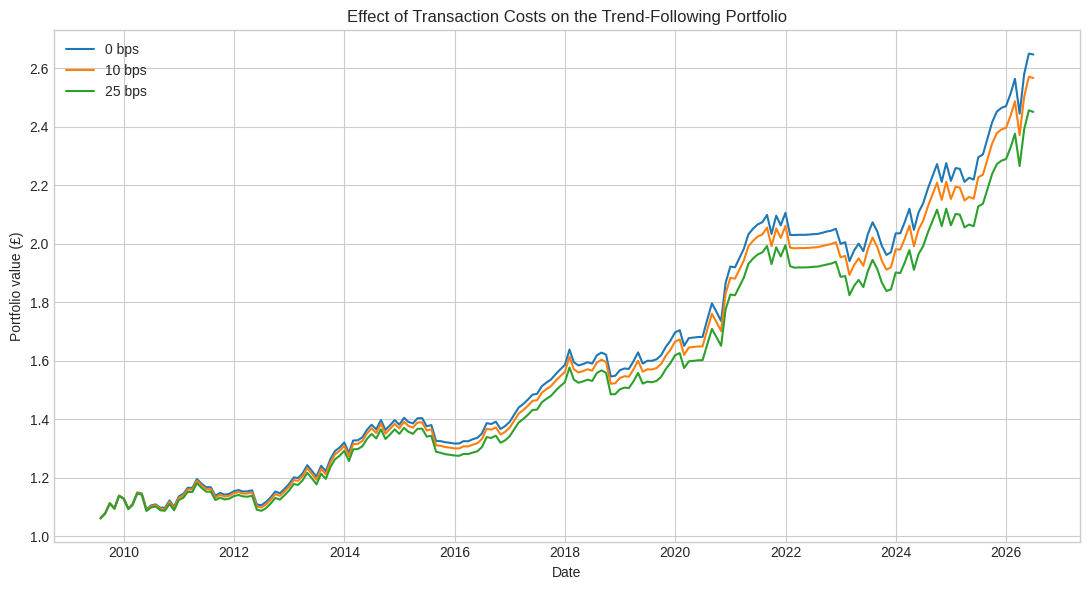

In [ ]:
# ---------------------------
# 13. Transaction costs
# ---------------------------

# Turnover measures how much the trend portfolio changes each month.
# For example, moving from 60% equities / 40% bonds
# to 60% equities / 40% cash gives turnover of 40%.

trend_turnover = (
    0.5
    * trend_weights.diff().abs().sum(axis=1)
)

# There is no previous allocation before the first month.
trend_turnover.iloc[0] = 0

display(trend_turnover.head())


# ---------------------------
# 14. Test different transaction costs
# ---------------------------

# Basis points:
# 0 bps  = no costs
# 10 bps = 0.1% cost per unit of turnover
# 25 bps = 0.25% cost per unit of turnover

transaction_costs_bps = [0, 10, 25]

transaction_cost_results = []

# Store wealth series so we can plot them afterwards
wealth_after_costs = {}

for cost_bps in transaction_costs_bps:

    # Convert basis points into a decimal.
    # For example, 10 bps becomes 0.001.
    cost_rate = cost_bps / 10000

    # Cost in each month depends on the amount traded.
    monthly_cost = cost_rate * trend_turnover

    # Deduct costs from the monthly growth rate.
    returns_after_costs = (
        (1 + trend_returns)
        * (1 - monthly_cost)
        - 1
    )

    # Calculate wealth and drawdown after costs.
    wealth_after_cost = (
        1 + returns_after_costs
    ).cumprod()

    drawdown_after_cost = (
        wealth_after_cost / wealth_after_cost.cummax() - 1
    )

    # Calculate the performance measures.
    cagr_after_cost = (
        wealth_after_cost.iloc[-1] ** (1 / years) - 1
    )

    volatility_after_cost = (
        returns_after_costs.std() * np.sqrt(12)
    )

    excess_returns_after_cost = (
        returns_after_costs - analysis_returns["Cash"]
    )

    sharpe_after_cost = (
        excess_returns_after_cost.mean()
        / excess_returns_after_cost.std()
        * np.sqrt(12)
    )

    maximum_drawdown_after_cost = (
        drawdown_after_cost.min()
    )

    # Save the result for this cost assumption.
    transaction_cost_results.append(
        {
            "Transaction costs": f"{cost_bps} bps",
            "Final value of £1": wealth_after_cost.iloc[-1],
            "CAGR": cagr_after_cost,
            "Annualised volatility": volatility_after_cost,
            "Sharpe ratio": sharpe_after_cost,
            "Maximum drawdown": maximum_drawdown_after_cost
        }
    )

    wealth_after_costs[cost_bps] = wealth_after_cost


# Create and display the transaction-cost table.
transaction_cost_table = pd.DataFrame(
    transaction_cost_results
)

display(transaction_cost_table)


# ---------------------------
# 15. Plot the effect of costs
# ---------------------------

plt.figure(figsize=(11, 6))

for cost_bps, wealth in wealth_after_costs.items():

    plt.plot(
        wealth.index,
        wealth,
        label=f"{cost_bps} bps"
    )

plt.title("Effect of Transaction Costs on the Trend-Following Portfolio")
plt.xlabel("Date")
plt.ylabel("Portfolio value (£)")
plt.legend()

plt.tight_layout()
plt.show()